# Exploratory Data Analysis & Intro

## Goal

1. Investigate top-paying roles and skills in the data science industry
2. Use Python to explore a real-live dataset on jop postings
3. For job-seekers: use these insights to help find the best job oppurtinites


## Final Deliverables:

1. Create Jupyter notebooks (Showing core skills in Python)
2. Create a summary page (via README.md) capturing your finding
3. Share this project via Github & Linkedin

## Question to Answer

1. What are the most demanded skills for the top 3 most popular data roles?
2. How are in-demands skills trending for Data Analysts?
3. How well do jobs and skills pay for Data Analyst?
4. What is the most optimal skill to learn  for Data Analysts? (High Demand Paying)

# Exploratory Data Analysis

### Roles to Explore

In [ ]:
# Importing libraries 
import pandas as pd
import ast
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns

# Loading data 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

### Filter For Indonesia Data Analyst Roles

In [ ]:
df_DA_INA = df[(df['job_country'] =='Indonesia') & (df['job_title_short'] == 'Data Analyst')].copy()

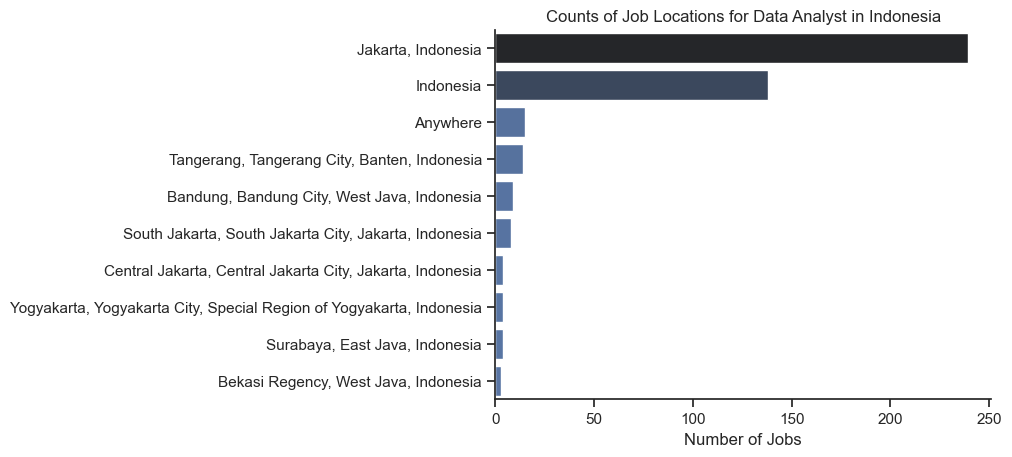

In [61]:
# kalau mau discard yg lokasi di jakarta doang / indonesia doang 
# df_test = df_DA_INA[~df_DA_INA['job_location'].isin(['Indonesia', 'Jakarta, Indonesia'])]

df_plot = df_DA_INA['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='job_location',hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Job Locations for Data Analyst in Indonesia')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()

### Job Oppurtunities

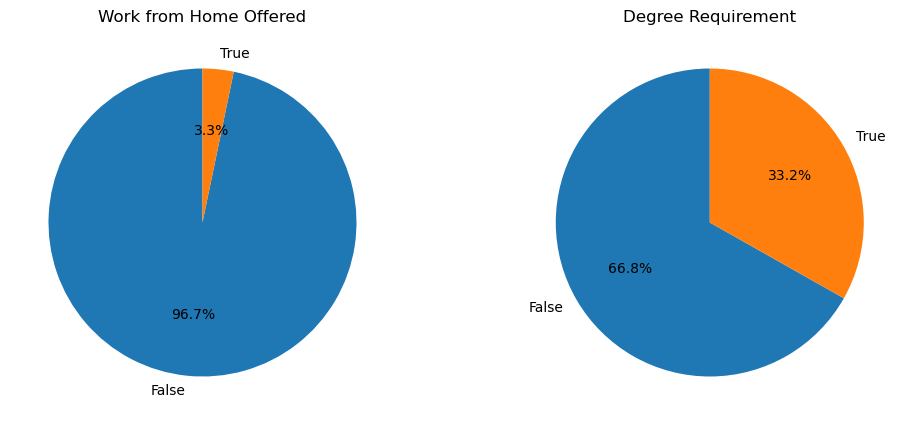

In [60]:
dict_column = {
    'job_work_from_home' : 'Work from Home Offered',
    'job_no_degree_mention' : 'Degree Requirement'
}

fig, ax = plt.subplots (1,2)
fig.set_size_inches((12,5))

for i , (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_INA[column].value_counts(), autopct='%1.1f%%', startangle=90, labels=[False, True])
    ax[i].set_title(title)
plt.show()

### Companies to Explore:

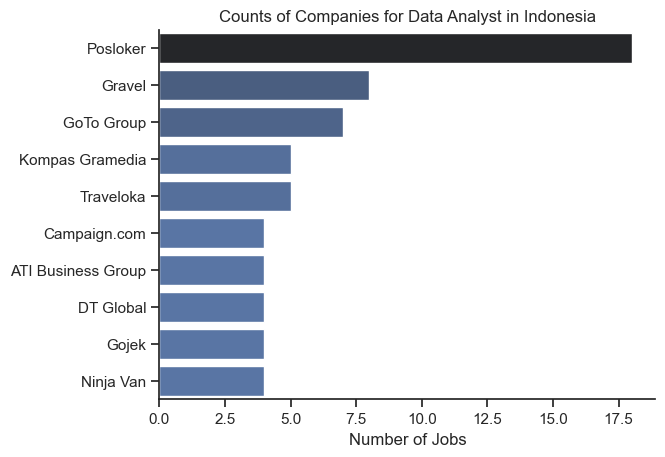

In [64]:
df_plot = df_DA_INA['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(data=df_plot, x='count', y='company_name',hue='count', palette='dark:b_r', legend=False)
sns.despine()
plt.title('Counts of Companies for Data Analyst in Indonesia')
plt.xlabel('Number of Jobs')
plt.ylabel('')
plt.show()